# Stock prediction AI made by Mikael Tsechoev, Zishan Khan, Mohamed Ahmed Elmi

#this AI works only inside the Dataset and wont give predictions in the future

In [1]:
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
!pip install numpy==1.19.5

In [2]:
df = web.DataReader('TSLA', data_source='yahoo', start='2011-01-01',end='2021-10-19')
df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2011-01-03,5.400000,5.180000,5.368000,5.324000,6415000.0,5.324000
2011-01-04,5.390000,5.204000,5.332000,5.334000,5937000.0,5.334000
2011-01-05,5.380000,5.238000,5.296000,5.366000,7233500.0,5.366000
2011-01-06,5.600000,5.362000,5.366000,5.576000,10306000.0,5.576000
2011-01-07,5.716000,5.580000,5.600000,5.648000,11239500.0,5.648000
...,...,...,...,...,...,...
2021-10-13,815.409973,805.780029,810.469971,811.080017,14120100.0,811.080017
2021-10-14,820.250000,813.349976,815.489990,818.320007,12247200.0,818.320007
2021-10-15,843.210022,822.349976,823.739990,843.030029,18818000.0,843.030029


In [3]:
#number of rows and coloumns
df.shape


(2718, 6)

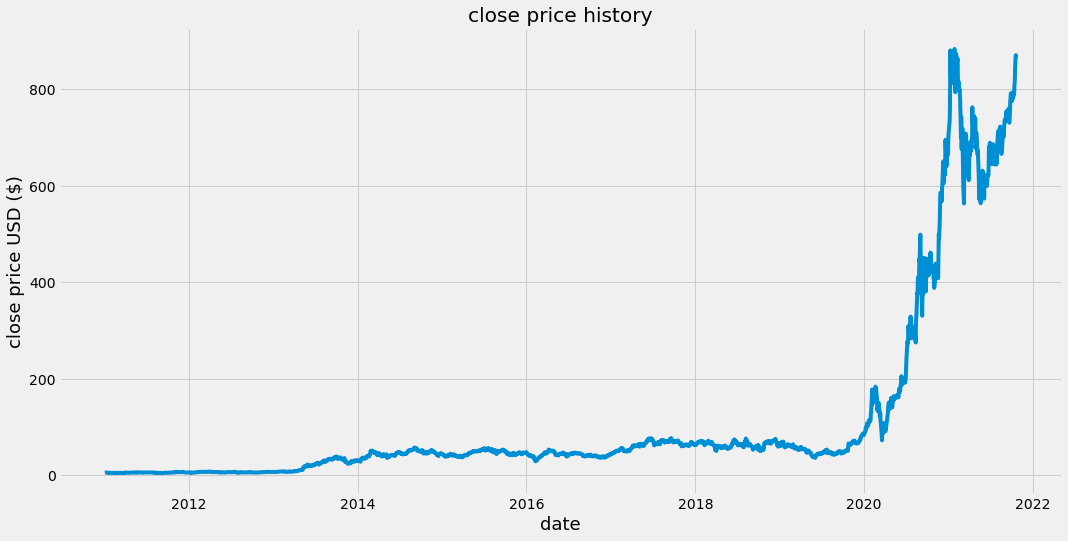

In [4]:
#visualizing the closing price history
plt.figure(figsize=(16,8))
plt.title('close price history')
plt.plot(df['Close'])
plt.xlabel('date', fontsize=18)
plt.ylabel('close price USD ($)', fontsize=18)
plt.show()

In [5]:
#new datafram with only the close coloumn
data = df.filter(['Close'])
#convert the datafram to a numpy array
dataset = data.values
#get the number of rows to train the model on
training_data_len = math.ceil(len(dataset)*.8) 

training_data_len


2175

In [6]:
#scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
scaled_data 

array([[0.00109022],
       [0.0011016 ],
       [0.00113801],
       ...,
       [0.95441117],
       [0.98522853],
       [0.97858257]])

In [7]:
#create the training dataset
#create the scaled training dataset
train_data = scaled_data [0:training_data_len , :]
#split the data into x_train and y_train datasets
x_train = []
y_train = []

for i in range (60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<=60:
        print(x_train)
        print(y_train)
        print()

        

[array([1.09021681e-03, 1.10159721e-03, 1.13801372e-03, 1.37699665e-03,
       1.45893312e-03, 1.50673003e-03, 1.16760210e-03, 1.16760210e-03,
       9.99175800e-04, 8.92202667e-04, 8.67166009e-04, 5.00726103e-04,
       1.79806159e-04, 2.75398895e-04, 6.05422831e-04, 6.48667474e-04,
       6.64599597e-04, 7.03292515e-04, 4.96173835e-04, 5.16658225e-04,
       4.73413582e-04, 4.80241712e-04, 4.09684549e-04, 3.70992174e-04,
       2.82227025e-04, 6.05422831e-04, 3.14091813e-04, 3.16367676e-04,
       3.23195806e-04, 2.84503430e-04, 2.29878390e-04, 6.60047872e-04,
       4.02856419e-04, 3.07263683e-04, 9.10399256e-06, 0.00000000e+00,
       1.59321769e-04, 4.05132824e-04, 4.68861315e-04, 4.80241712e-04,
       4.98449698e-04, 5.75834991e-04, 7.10120102e-04, 7.07844240e-04,
       6.44115749e-04, 6.57771467e-04, 4.96173835e-04, 5.09830095e-04,
       3.23195806e-04, 2.54915048e-04, 2.25326665e-04, 2.23050260e-04,
       2.57190910e-04, 2.04842275e-04, 8.19370184e-05, 8.64887433e-05,
     

In [8]:
#convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [9]:
#reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

(2115, 60, 1)

In [10]:
#build the lstm model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False,))
model.add(Dense(25))
model.add(Dense(1))


In [11]:
#compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


In [12]:
#train the model
model.fit(x_train, y_train, batch_size=1, epochs=1,)

2115/2115 [==============================] - 36s 17ms/step - loss: 3.5036e-05


In [16]:
#create the testing dataset
#create a new array containing scaled values from index 505 to 706
test_data = scaled_data[training_data_len - 60:, :]
#create the datasets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range (60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

In [17]:
#convert the data to a numpy array
x_test = np.array(x_test)

In [18]:
#reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
print(x_test.shape[0])


543


In [19]:
#get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


In [20]:
#get the root mean squared error (RMSE)
rmse=np.sqrt(np.mean(((predictions - y_test)**2)))
rmse


104.05691094075101

C:\Users\mikae\AppData\Local\Temp/ipykernel_28760/1618372487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


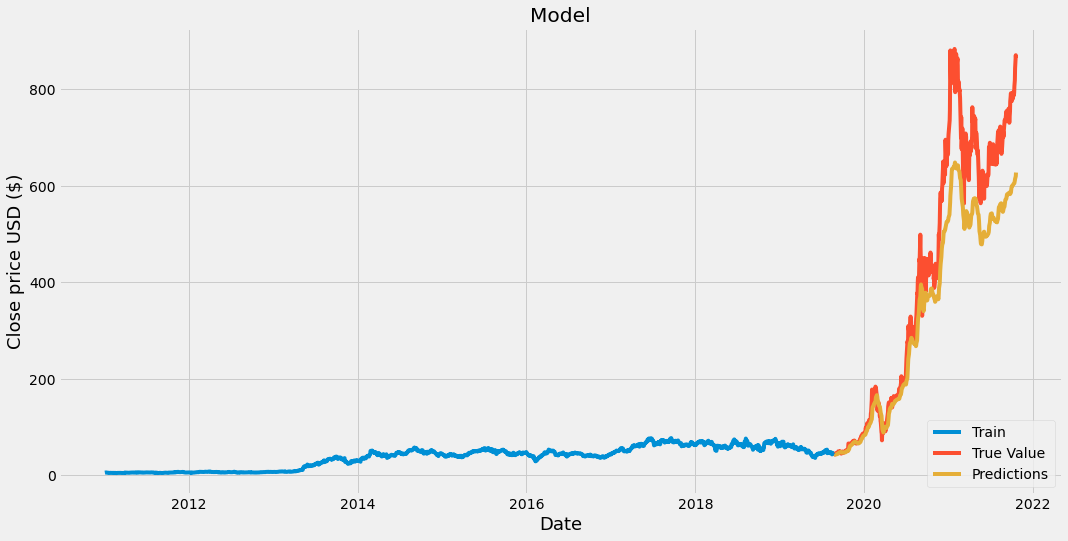

In [26]:
#plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#visualize the data
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close price USD ($)', fontsize = 18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'True Value', 'Predictions'], loc = 'lower right')
plt.show()


In [25]:
#input the day you want and it will give a prediction
day = input('input day (must be after 2019-08-26), format yyyy-mm-dd')
print('predicted value=',valid['Predictions'].loc[day])
print('true value=',valid['Close'].loc[day])


input day (must be after 2019-08-26), format yyyy-mm-dd2019-10-10
predicted value= 47.09523
true value= 48.948001861572266
